# Test 3: Remove Duplicate Branch

**Purpose**: Remove the separate transformed branch entirely and feed only the classical features into the prediction head, so this test measures whether the extra branch itself was helping.

This notebook keeps the same data pipeline and training loop style as Tests 1 and 2, but removes both the extra branch and its residual path.

**Targets**: `log_H2O`, `log_CO2`, `log_CO`, `log_CH4`, `log_NH3`

## 1. Configuration

In [1]:
import json
import math
import os
import random
import time
from pathlib import Path

os.environ.setdefault("XDG_CACHE_HOME", str(Path("../.cache").resolve()))
os.environ.setdefault("MPLCONFIGDIR", str(Path("../.matplotlib-cache").resolve()))

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from IPython.display import display
from sklearn.model_selection import train_test_split

try:
    from tqdm.auto import tqdm
except ImportError:
    class _TqdmFallback:
        def __init__(self, iterable=None, total=None, desc=None, leave=True):
            self.iterable = iterable

        def __iter__(self):
            return iter(self.iterable)

        def set_postfix(self, **kwargs):
            pass

        @staticmethod
        def write(message):
            print(message)

    def tqdm(iterable=None, total=None, desc=None, leave=True):
        return _TqdmFallback(iterable=iterable, total=total, desc=desc, leave=leave)

AUX_FEATURE_COLS = [
    "star_mass_kg", "star_radius_m", "star_temperature",
    "planet_mass_kg", "planet_orbital_period", "planet_distance",
    "planet_surface_gravity", "log10_noise_mean",
]
TARGET_COLS = ["log_H2O", "log_CO2", "log_CO", "log_CH4", "log_NH3"]

SEED = 42
DATA_ROOT_CANDIDATES = [
    Path("../FullDataset"),
    Path("FullDataset"),
    Path("../ariel-ml-dataset"),
    Path("ariel-ml-dataset"),
]
OUTPUT_DIR = Path("../outputs/no_vqc_test3")
TRAIN_BATCH_SIZE = 256
EVAL_BATCH_SIZE = 8192
MAX_EPOCHS = 30
EARLY_STOP_PATIENCE = 6
SCHEDULER_PATIENCE = 5
CLASSICAL_LR = 2e-3
WEIGHT_DECAY = 1e-4
GRADIENT_CLIP = 5.0
DROPOUT = 0.05
VAL_FRACTION = 0.10

AUX_HIDDEN = 64
AUX_OUT = 32
SPECTRAL_HIDDEN = 64
SPECTRAL_OUT = 32
FUSION_HIDDEN = 48
HEAD_HIDDEN = 96
LATENT_DIM = 12


def resolve_data_root(candidates):
    for root in candidates:
        train_dir = root / "TrainingData"
        if (train_dir / "AuxillaryTable.csv").exists() and (train_dir / "SpectralData.hdf5").exists():
            return root
    searched = "\n".join(f" - {path.resolve()}" for path in candidates)
    raise FileNotFoundError(
        "Could not locate the Ariel dataset. Put the extracted dataset in one of:\n"
        f"{searched}"
    )


DATA_ROOT = resolve_data_root(DATA_ROOT_CANDIDATES)
DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

print("Test 3: Remove duplicate branch")
print(f"PyTorch: {torch.__version__}")
print(f"Data root: {DATA_ROOT.resolve()}")
print(f"Device: {DEVICE}")
print(f"Latent dimension: {LATENT_DIM}")

Test 3: Remove duplicate branch
PyTorch: 2.10.0
Data root: /Users/jkw/Documents/uni/axion/hack4sages/FullDataset
Device: mps
Latent dimension: 12


/Users/jkw/Documents/uni/axion/hack4sages/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

cpu_threads = max(1, min(os.cpu_count() or 1, 32))
torch.set_num_threads(cpu_threads)

try:
    torch.set_num_interop_threads(max(1, min(cpu_threads // 2, 8)))
except RuntimeError as exc:
    print(f"Skipping torch.set_num_interop_threads: {exc}")

## 2. Data Loading & Preprocessing

In [3]:
aux_path = DATA_ROOT / "TrainingData" / "AuxillaryTable.csv"
target_path = DATA_ROOT / "TrainingData" / "Ground Truth Package" / "FM_Parameter_Table.csv"
spectra_path = DATA_ROOT / "TrainingData" / "SpectralData.hdf5"

aux_df = pd.read_csv(aux_path)
targets = pd.read_csv(target_path)
labels = aux_df.merge(targets[["planet_ID"] + TARGET_COLS], on="planet_ID", how="inner").reset_index(drop=True)

with h5py.File(spectra_path, "r") as h5f:
    first_key = labels.loc[0, "planet_ID"]
    first_group = h5f[f"Planet_{first_key}"]
    wavelength_um = np.asarray(first_group["instrument_wlgrid"][:], dtype=np.float32)
    n_bins = len(wavelength_um)
    noisy_spectra = np.empty((len(labels), n_bins), dtype=np.float32)
    noise_arr = np.empty((len(labels), n_bins), dtype=np.float32)

    for i, pid in enumerate(labels["planet_ID"].values):
        grp = h5f[f"Planet_{pid}"]
        noisy_spectra[i] = grp["instrument_spectrum"][:]
        noise_arr[i] = grp["instrument_noise"][:]

labels["log10_noise_mean"] = np.log10(np.clip(noise_arr.mean(axis=1), 1e-10, None))
planet_id_aux = labels["planet_ID"].to_numpy()
aux_features = labels[AUX_FEATURE_COLS].to_numpy(dtype=np.float32)
target_values = labels[TARGET_COLS].to_numpy(dtype=np.float32)
spectra = noisy_spectra.reshape(noisy_spectra.shape[0], 1, noisy_spectra.shape[1]).astype(np.float32)

print(f"Auxiliary features shape: {aux_features.shape}")
print(f"Spectra shape: {spectra.shape}")
print(f"Targets shape: {target_values.shape}")
display(labels.head(2))
display(targets.head(2))

Auxiliary features shape: (41423, 8)
Spectra shape: (41423, 1, 52)
Targets shape: (41423, 5)


,planet_ID,star_distance,star_mass_kg,star_radius_m,star_temperature,planet_mass_kg,planet_orbital_period,planet_distance,planet_surface_gravity,log_H2O,log_CO2,log_CO,log_CH4,log_NH3,log10_noise_mean
0,train1,530.765,1.968526e+30,667872000.0,5636.0,3.990923e+26,9.668577,0.088530,16.642039,-8.865868,-6.700707,-5.557561,-8.957615,-3.097540,-4.591440
1,train2,440.089,1.948642e+30,723528000.0,5449.0,4.977001e+26,4.218028,0.050752,5.197135,-4.510258,-8.228966,-3.565427,-7.807424,-3.633658,-3.727626


,Unnamed: 0,planet_ID,planet_radius,planet_temp,log_H2O,log_CO2,log_CO,log_CH4,log_NH3
0,0,train1,0.559620,863.394770,-8.865868,-6.700707,-5.557561,-8.957615,-3.097540
1,1,train2,1.118308,1201.700465,-4.510258,-8.228966,-3.565427,-7.807424,-3.633658


In [4]:
class StandardScalerNumpy:
    def __init__(self, eps=1e-8):
        self.eps = eps
        self.mean_ = None
        self.scale_ = None

    def fit(self, x):
        x = np.asarray(x, dtype=np.float32)
        self.mean_ = x.mean(axis=0)
        self.scale_ = x.std(axis=0)
        self.scale_ = np.where(self.scale_ < self.eps, 1.0, self.scale_)
        return self

    def transform(self, x):
        x = np.asarray(x, dtype=np.float32)
        return (x - self.mean_) / self.scale_

    def inverse_transform(self, x):
        x = np.asarray(x, dtype=np.float32)
        return x * self.scale_ + self.mean_

    def to_dict(self):
        return {
            "mean": self.mean_.tolist(),
            "scale": self.scale_.tolist(),
        }

indices = np.arange(len(aux_features))
train_idx, temp_idx = train_test_split(indices, test_size=0.20, random_state=SEED, shuffle=True)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.50, random_state=SEED, shuffle=True)

train_aux_raw = aux_features[train_idx]
val_aux_raw = aux_features[val_idx]
test_aux_raw = aux_features[test_idx]

train_spec_raw = spectra[train_idx]
val_spec_raw = spectra[val_idx]
test_spec_raw = spectra[test_idx]

train_tgt_raw = target_values[train_idx]
val_tgt_raw = target_values[val_idx]
test_tgt_raw = target_values[test_idx]

aux_scaler = StandardScalerNumpy().fit(train_aux_raw)
spec_scaler = StandardScalerNumpy().fit(train_spec_raw.reshape(train_spec_raw.shape[0], -1))
tgt_scaler = StandardScalerNumpy().fit(train_tgt_raw)

train_aux_scaled = aux_scaler.transform(train_aux_raw)
val_aux_scaled = aux_scaler.transform(val_aux_raw)
test_aux_scaled = aux_scaler.transform(test_aux_raw)

train_spec_scaled = spec_scaler.transform(train_spec_raw.reshape(train_spec_raw.shape[0], -1)).reshape(train_spec_raw.shape)
val_spec_scaled = spec_scaler.transform(val_spec_raw.reshape(val_spec_raw.shape[0], -1)).reshape(val_spec_raw.shape)
test_spec_scaled = spec_scaler.transform(test_spec_raw.reshape(test_spec_raw.shape[0], -1)).reshape(test_spec_raw.shape)

train_tgt_scaled = tgt_scaler.transform(train_tgt_raw)
val_tgt_scaled = tgt_scaler.transform(val_tgt_raw)
test_tgt_scaled = tgt_scaler.transform(test_tgt_raw)

train_aux = torch.tensor(train_aux_scaled, dtype=torch.float32)
val_aux = torch.tensor(val_aux_scaled, dtype=torch.float32)
test_aux = torch.tensor(test_aux_scaled, dtype=torch.float32)

train_spec = torch.tensor(train_spec_scaled, dtype=torch.float32)
val_spec = torch.tensor(val_spec_scaled, dtype=torch.float32)
test_spec = torch.tensor(test_spec_scaled, dtype=torch.float32)

train_tgt = torch.tensor(train_tgt_scaled, dtype=torch.float32)
val_tgt = torch.tensor(val_tgt_scaled, dtype=torch.float32)
test_tgt = torch.tensor(test_tgt_scaled, dtype=torch.float32)

print(f"Train/val/test sizes: {len(train_idx)} / {len(val_idx)} / {len(test_idx)}")

Train/val/test sizes: 33138 / 4142 / 4143


/Users/jkw/Documents/uni/axion/hack4sages/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:190: RuntimeWarning: overflow encountered in square
  x = um.square(x, out=x)


## 3. Model Definition

In [5]:
class AuxEncoder(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, dropout=DROPOUT):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, x):
        return self.net(x)


class SpectralEncoder(nn.Module):
    def __init__(self, out_dim, hidden_dim=SPECTRAL_HIDDEN, dropout=DROPOUT):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(1, 8, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.Conv1d(8, 16, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
        )
        self.proj = nn.Sequential(
            nn.Linear(16, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, x):
        return self.proj(self.features(x))


class FusionEncoder(nn.Module):
    def __init__(self, aux_dim, spec_dim, hidden_dim, latent_dim, dropout=DROPOUT):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(aux_dim + spec_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, latent_dim),
        )

    def forward(self, aux_feat, spec_feat):
        return self.net(torch.cat([aux_feat, spec_feat], dim=-1))


class NoBranchHead(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, dropout=DROPOUT):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, head_in):
        return self.mlp(head_in)


class RemoveDuplicateBranchModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.aux_enc = AuxEncoder(len(AUX_FEATURE_COLS), AUX_HIDDEN, AUX_OUT)
        self.spec_enc = SpectralEncoder(SPECTRAL_OUT)
        self.fusion = FusionEncoder(AUX_OUT, SPECTRAL_OUT, FUSION_HIDDEN, LATENT_DIM)
        self.head = NoBranchHead(LATENT_DIM + AUX_OUT + SPECTRAL_OUT, HEAD_HIDDEN, len(TARGET_COLS))

    def forward(self, aux, spectra):
        aux_feat = self.aux_enc(aux)
        spec_feat = self.spec_enc(spectra)
        latent = self.fusion(aux_feat, spec_feat)
        head_in = torch.cat([latent, aux_feat, spec_feat], dim=-1)
        return self.head(head_in)


model = RemoveDuplicateBranchModel().to(DEVICE)
model

RemoveDuplicateBranchModel(
  (aux_enc): AuxEncoder(
    (net): Sequential(
      (0): Linear(in_features=8, out_features=64, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.05, inplace=False)
      (3): Linear(in_features=64, out_features=32, bias=True)
    )
  )
  (spec_enc): SpectralEncoder(
    (features): Sequential(
      (0): Conv1d(1, 8, kernel_size=(5,), stride=(1,), padding=(2,))
      (1): ReLU()
      (2): Conv1d(8, 16, kernel_size=(5,), stride=(1,), padding=(2,))
      (3): ReLU()
      (4): AdaptiveAvgPool1d(output_size=1)
      (5): Flatten(start_dim=1, end_dim=-1)
    )
    (proj): Sequential(
      (0): Linear(in_features=16, out_features=64, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.05, inplace=False)
      (3): Linear(in_features=64, out_features=32, bias=True)
    )
  )
  (fusion): FusionEncoder(
    (net): Sequential(
      (0): Linear(in_features=64, out_features=48, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.05, inplace=False)
      (3): Li

## 4. Training

In [6]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

loss_fn = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=CLASSICAL_LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=SCHEDULER_PATIENCE,
)


def rmse_by_target(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2, axis=0))


@torch.no_grad()
def predict_scaled(aux, spec):
    model.eval()
    preds = []
    for start in range(0, len(aux), EVAL_BATCH_SIZE):
        batch_aux = aux[start:start + EVAL_BATCH_SIZE].to(DEVICE)
        batch_spec = spec[start:start + EVAL_BATCH_SIZE].to(DEVICE)
        batch_pred = model(batch_aux, batch_spec)
        preds.append(batch_pred.detach().cpu())
    return torch.cat(preds, dim=0).numpy()


@torch.no_grad()
def evaluate_split(name, aux, spec, tgt_scaled, tgt_raw):
    pred_scaled = predict_scaled(aux, spec)
    pred_raw = tgt_scaler.inverse_transform(pred_scaled)
    split_rmse = rmse_by_target(tgt_raw, pred_raw)
    return {
        "split": name,
        "mean_rmse": float(split_rmse.mean()),
        "per_target_rmse": {col: float(val) for col, val in zip(TARGET_COLS, split_rmse)},
        "pred_raw": pred_raw,
    }


history = []
best_state = None
best_val_rmse = math.inf
best_epoch = -1
stale_epochs = 0
n_train = len(train_aux)
batch_starts = list(range(0, n_train, TRAIN_BATCH_SIZE))
print(f"Training: {n_train} samples, {len(batch_starts)} batches/epoch, max {MAX_EPOCHS} epochs")

start_time = time.time()
for epoch in range(MAX_EPOCHS):
    model.train()
    perm = torch.randperm(n_train)
    batch_losses = []
    progress = tqdm(batch_starts, total=len(batch_starts), desc=f"Epoch {epoch + 1}/{MAX_EPOCHS}", leave=False)

    for batch_num, b in enumerate(progress, start=1):
        idx = perm[b:b + TRAIN_BATCH_SIZE]
        batch_aux = train_aux[idx].to(DEVICE)
        batch_spec = train_spec[idx].to(DEVICE)
        batch_tgt = train_tgt[idx].to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        pred = model(batch_aux, batch_spec)
        loss = loss_fn(pred, batch_tgt)
        loss.backward()
        if GRADIENT_CLIP is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP)
        optimizer.step()

        loss_value = float(loss.detach().cpu())
        batch_losses.append(loss_value)
        progress.set_postfix(loss=f"{loss_value:.5f}")
        if batch_num % 25 == 0 or batch_num == len(batch_starts):
            tqdm.write(f"Epoch {epoch + 1:2d} | Batch {batch_num:3d}/{len(batch_starts)} | loss={loss_value:.5f}")

    train_loss = float(np.mean(batch_losses))
    val_metrics = evaluate_split("val", val_aux, val_spec, val_tgt_scaled, val_tgt_raw)
    val_rmse = val_metrics["mean_rmse"]
    scheduler.step(val_rmse)

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_rmse": val_rmse,
        "lr": float(optimizer.param_groups[0]["lr"]),
    })

    rmse_str = ", ".join(f"{name}={value:.4f}" for name, value in val_metrics["per_target_rmse"].items())
    print(f"Epoch {epoch + 1:2d} | train_loss={train_loss:.5f} | val_mean_rmse={val_rmse:.5f}")
    print(f"  Validation RMSE: {rmse_str}")

    if val_rmse < best_val_rmse:
        best_val_rmse = val_rmse
        best_epoch = epoch + 1
        best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
        stale_epochs = 0
    else:
        stale_epochs += 1
        if stale_epochs >= EARLY_STOP_PATIENCE:
            print(f"Early stopping at epoch {epoch + 1}.")
            break

elapsed = time.time() - start_time
if best_state is None:
    raise RuntimeError("Training finished without capturing a best model state.")

model.load_state_dict(best_state)
print(f"Best epoch: {best_epoch} | best val mean RMSE: {best_val_rmse:.5f} | elapsed: {elapsed:.1f}s")

Training: 33138 samples, 130 batches/epoch, max 30 epochs


Epoch 1/30:  29%|▎| 38/130 [00:03<00:03, 23.71it/s, loss=0.95715

Epoch  1 | Batch  25/130 | loss=0.96729


Epoch 1/30:  48%|▍| 63/130 [00:03<00:01, 46.68it/s, loss=0.98488

Epoch  1 | Batch  50/130 | loss=0.99305


...

Epoch 30/30:  30%|▎| 39/130 [00:00<00:00, 128.63it/s, loss=0.989

Epoch 30 | Batch  25/130 | loss=0.94498
Epoch 30 | Batch  50/130 | loss=0.98989


Epoch 30/30:  72%|▋| 93/130 [00:00<00:00, 129.79it/s, loss=0.979

Epoch 30 | Batch  75/130 | loss=0.98957
Epoch 30 | Batch 100/130 | loss=0.97844


Epoch 30 | Batch 125/130 | loss=1.01542
Epoch 30 | Batch 130/130 | loss=1.02755
Epoch 30 | train_loss=0.98873 | val_mean_rmse=1.43723
  Validation RMSE: log_H2O=1.7240, log_CO2=1.4351, log_CO=0.8731, log_CH4=1.7177, log_NH3=1.4362
Best epoch: 27 | best val mean RMSE: 1.43521 | elapsed: 36.0s


## 5. Evaluation & Artifact Saving

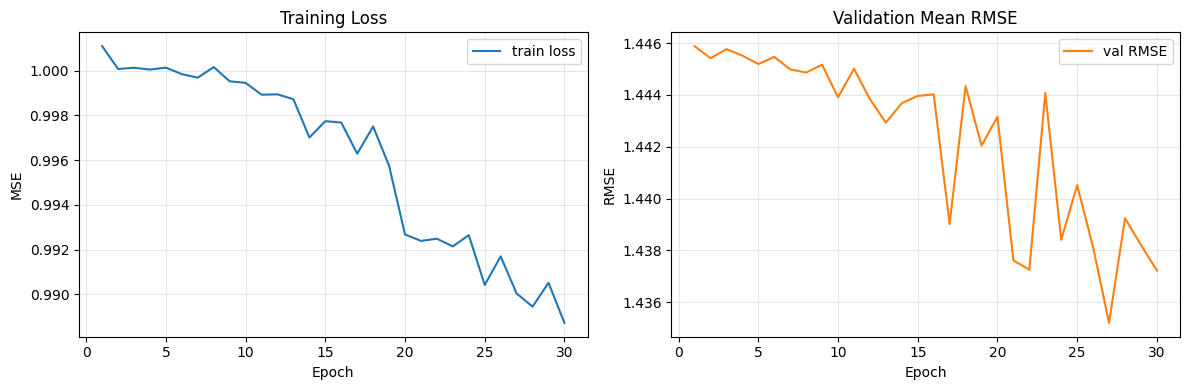

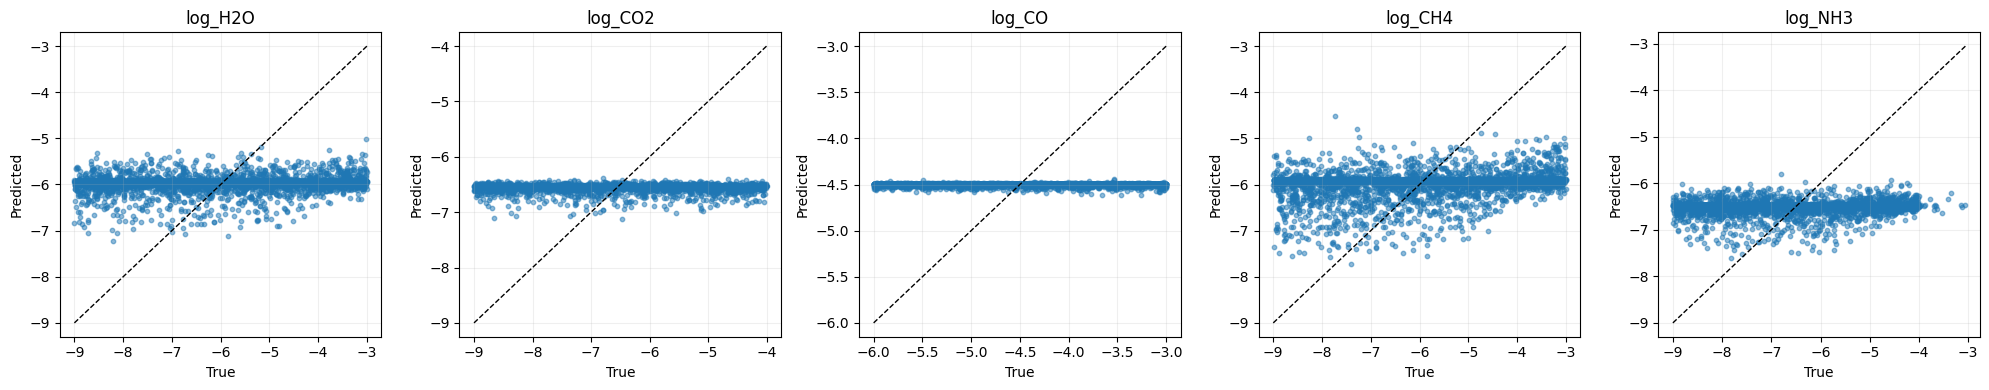

{
  "experiment": "Test 3: Remove Duplicate Branch",
  "description": "No transformed branch and no residual path; the head consumes only latent, auxiliary, and spectral features.",
  "seed": 42,
  "device": "mps",
  "best_epoch": 27,
  "best_val_mean_rmse": 1.4352080821990967,
  "val_mean_rmse": 1.4352080821990967,
  "test_mean_rmse": 1.4377224445343018,
  "val_per_target_rmse": {
    "log_H2O": 1.719728708267212,
    "log_CO2": 1.4369739294052124,
    "log_CO": 0.8716927766799927,
    "log_CH4": 1.7137303352355957,
    "log_NH3": 1.4339147806167603
  },
  "test_per_target_rmse": {
    "log_H2O": 1.7345008850097656,
    "log_CO2": 1.428328514099121,
    "log_CO": 0.8762723803520203,
    "log_CH4": 1.6974347829818726,
    "log_NH3": 1.4520756006240845
  },
  "train_size": 33138,
  "val_size": 4142,
  "test_size": 4143
}
Saved history to: ../outputs/no_vqc_test3/training_history.csv
Saved predictions to: ../outputs/no_vqc_test3/test_predictions.csv
Saved scalers to: ../outputs/no_vqc_te

In [7]:
history_df = pd.DataFrame(history)
val_metrics = evaluate_split("val", val_aux, val_spec, val_tgt_scaled, val_tgt_raw)
test_metrics = evaluate_split("test", test_aux, test_spec, test_tgt_scaled, test_tgt_raw)

test_predictions = pd.DataFrame(test_metrics["pred_raw"], columns=[f"pred_{col}" for col in TARGET_COLS])
for col in TARGET_COLS:
    test_predictions[f"true_{col}"] = test_tgt_raw[:, TARGET_COLS.index(col)]
test_predictions.insert(0, "planet_ID", planet_id_aux[test_idx])

summary = {
    "experiment": "Test 3: Remove Duplicate Branch",
    "description": "No transformed branch and no residual path; the head consumes only latent, auxiliary, and spectral features.",
    "seed": SEED,
    "device": str(DEVICE),
    "best_epoch": best_epoch,
    "best_val_mean_rmse": best_val_rmse,
    "val_mean_rmse": val_metrics["mean_rmse"],
    "test_mean_rmse": test_metrics["mean_rmse"],
    "val_per_target_rmse": val_metrics["per_target_rmse"],
    "test_per_target_rmse": test_metrics["per_target_rmse"],
    "train_size": int(len(train_idx)),
    "val_size": int(len(val_idx)),
    "test_size": int(len(test_idx)),
}

history_path = OUTPUT_DIR / "training_history.csv"
predictions_path = OUTPUT_DIR / "test_predictions.csv"
scalers_path = OUTPUT_DIR / "scalers.json"
summary_path = OUTPUT_DIR / "summary.json"
checkpoint_path = OUTPUT_DIR / "model.pt"

history_df.to_csv(history_path, index=False)
test_predictions.to_csv(predictions_path, index=False)
with open(scalers_path, "w", encoding="utf-8") as f:
    json.dump(
        {
            "aux": aux_scaler.to_dict(),
            "spectra": spec_scaler.to_dict(),
            "targets": tgt_scaler.to_dict(),
        },
        f,
        indent=2,
    )
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)
torch.save({"model_state_dict": model.state_dict(), "summary": summary}, checkpoint_path)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_df["epoch"], history_df["train_loss"], label="train loss")
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE")
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_df["epoch"], history_df["val_rmse"], label="val RMSE", color="tab:orange")
axes[1].set_title("Validation Mean RMSE")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("RMSE")
axes[1].grid(True, alpha=0.3)

for ax in axes:
    ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "training_curves.png", dpi=200, bbox_inches="tight")
plt.show()

ncols = len(TARGET_COLS)
fig, axes = plt.subplots(1, ncols, figsize=(4 * ncols, 4), squeeze=False)
for idx, target in enumerate(TARGET_COLS):
    ax = axes[0, idx]
    ax.scatter(test_tgt_raw[:, idx], test_metrics["pred_raw"][:, idx], s=10, alpha=0.5)
    min_v = min(test_tgt_raw[:, idx].min(), test_metrics["pred_raw"][:, idx].min())
    max_v = max(test_tgt_raw[:, idx].max(), test_metrics["pred_raw"][:, idx].max())
    ax.plot([min_v, max_v], [min_v, max_v], linestyle="--", color="black", linewidth=1)
    ax.set_title(target)
    ax.set_xlabel("True")
    ax.set_ylabel("Predicted")
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "test_scatter.png", dpi=200, bbox_inches="tight")
plt.show()

print(json.dumps(summary, indent=2))
print(f"Saved history to: {history_path}")
print(f"Saved predictions to: {predictions_path}")
print(f"Saved scalers to: {scalers_path}")
print(f"Saved summary to: {summary_path}")
print(f"Saved checkpoint to: {checkpoint_path}")